In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
df = pd.read_csv("../data/paysim.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 6,362,620
Columns: 11


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [7]:
df.sample(10, random_state=42)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0
3494160,259,PAYMENT,915.13,C2002954533,0.00,0.00,M290849763,0.00,0.00,0,0
2331654,188,CASH_OUT,20603.87,C813757373,0.00,0.00,C823291717,558068.66,578672.53,0,0
1414955,139,CASH_OUT,58605.72,C1850864812,0.00,0.00,C618657299,585494.94,644100.66,0,0
2938135,230,PAYMENT,4865.11,C886849972,0.00,0.00,M623175144,0.00,0.00,0,0
6133806,544,CASH_OUT,118131.63,C390714641,0.00,0.00,C366360355,8131691.35,8476246.86,0,0


In [8]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
fraud_rate = (
    df["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
)

fraud_rate

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [10]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [11]:
# | Column         | Meaning                           |
# | -------------- | --------------------------------- |
# | step           | Hour in the simulation            |
# | type           | Transaction type                  |
# | amount         | Money transferred                 |
# | nameOrig       | Sender account                    |
# | oldbalanceOrg  | Sender balance before transaction |
# | newbalanceOrig | Sender balance after transaction  |
# | nameDest       | Receiver account                  |
# | oldbalanceDest | Receiver balance before           |
# | newbalanceDest | Receiver balance after            |
# | isFraud        | Actual fraud label                |
# | isFlaggedFraud | Existing rule-based fraud flag    |

In [12]:
# Which transaction types have the highest fraud rates?
# Does transaction amount influence fraud likelihood?
# How often does the rule-based system correctly identify fraud?
# Can machine learning improve fraud detection?
# What characteristics distinguish fraudulent transactions?

In [13]:
## Initial Data Understanding Findings

# - The dataset contains 6,362,620 transactions across 11 features
# - No missing values were identified, meaning no additional imputation or missing data handling is required
# - No duplicate records were found
# - The dataset contains both numerical and categorical variables:
#     - Numerical features include transaction amounts, account balances, and fraud indicators
#     - Categorical features include transaction type and customer identifiers
# - The target variable is 'isFraud', where:
#     - '0' represents legitimate transactions.
#     - '1' represents fraudulent transactions.

target = "isFraud"

# The dataset is highly imbalanced:
# - Legitimate transactions: 6,354,407
# - Fraudulent transactions: 8,213

# Because fraudulent transactions represent a very small percentage of total activity, accuracy alone will not be an appropriate evaluation metric
# Model performance will instead be evaluated using metrics such as precision, recall, F1-score, and ROC-AUC

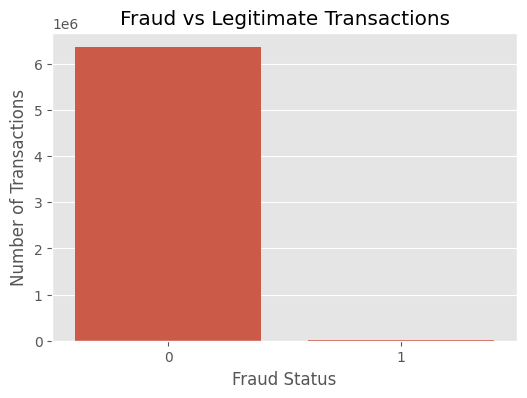

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

plt.savefig(
    "../images/fraud_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [15]:
fraud_rate = (
    df["isFraud"]
    .mean()
    * 100
)

print(f"Fraud Rate: {fraud_rate:.3f}%")

Fraud Rate: 0.129%


In [16]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

fraud_by_type

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [17]:
#Transfer more likely to be fradulent 
#Cash out next most likely
#The rest are very unlikely

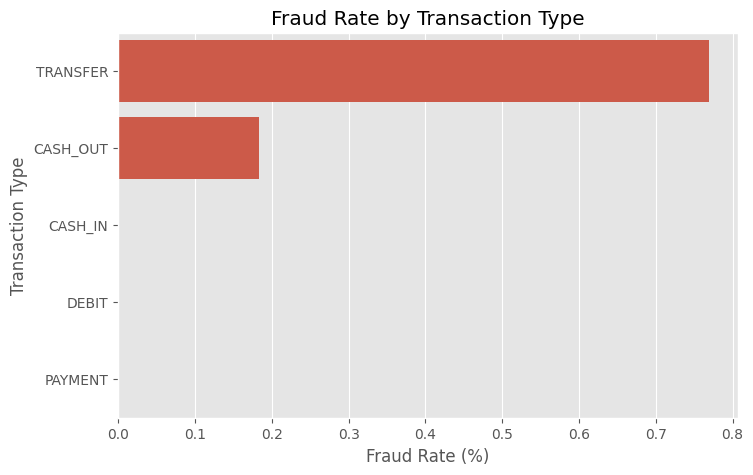

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=fraud_by_type.values,
    y=fraud_by_type.index
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Transaction Type")

plt.show()

In [19]:
transaction_volume = df["type"].value_counts()

transaction_volume

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

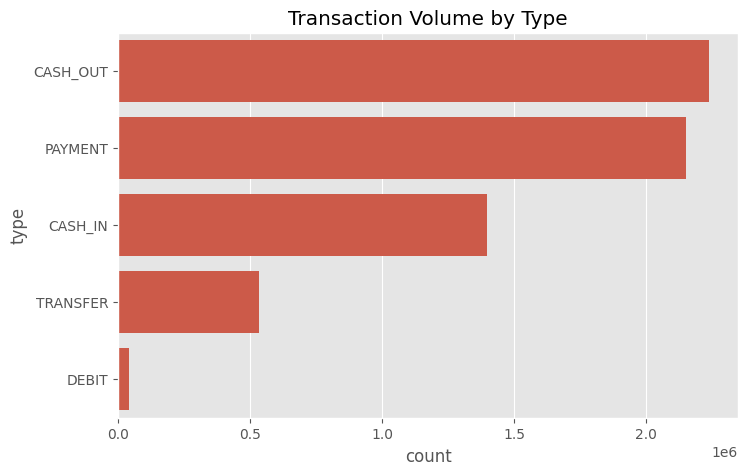

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="type",
    order=df["type"].value_counts().index
)

plt.title("Transaction Volume by Type")

plt.show()

In [21]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


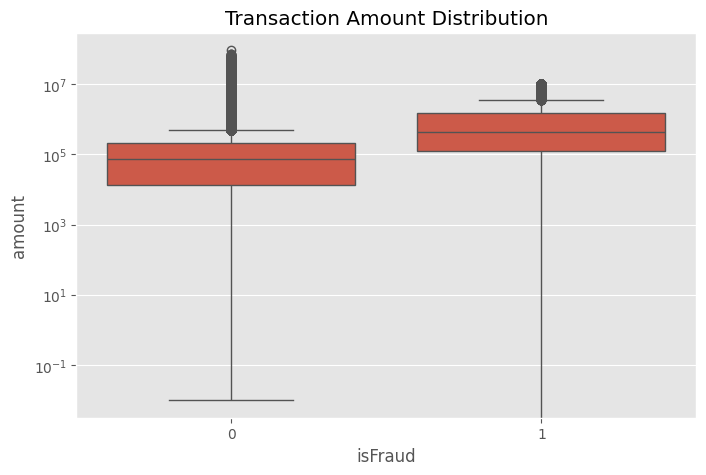

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

plt.yscale("log")

plt.title("Transaction Amount Distribution")

plt.show()

In [23]:
#Fradulent transactions generally have higher transaction amounts compared to legitimate transactions

In [24]:
#Checking Account Balance Behavior
df["origin_balance_change"] = (
    df["oldbalanceOrg"] -
    df["newbalanceOrig"]
)

df.groupby("isFraud")["origin_balance_change"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,-2.314152e+04,1.062233e+05,-1915267.9,0.00,0.00,10102.125,4164236.31
1,8213.0,1.457275e+06,2.396099e+06,0.0,124582.58,436317.49,1503034.860,10000000.00


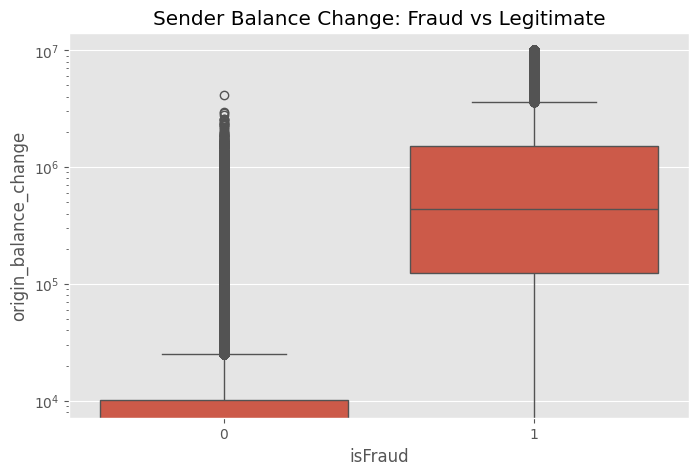

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="origin_balance_change"
)

plt.yscale("log")

plt.title("Sender Balance Change: Fraud vs Legitimate")

plt.show()

In [26]:
# Fraudulent transactions generally involve larger reductions in the sender's account balance
# Fraud often attempts to transfer or withdraw large portions of available funds

In [27]:
df.groupby("isFraud")[[
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]].mean()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
isFraud,,,,
0,8.328287e+05,855970.228109,1.101421e+06,1.224926e+06
1,1.649668e+06,192392.631836,5.442496e+05,1.279708e+06


In [28]:
## Account Balance Behavior Analysis

# Fraudulent transactions show different balance patterns compared to legitimate transactions

# Fraud cases typically involve large reductions in the sender's account balance and large increases in the destination account balance
# This suggests that balance movement patterns may provide valuable signals for detecting fraudulent activity


In [29]:
#Existing System
pd.crosstab(
    df["isFraud"],
    df["isFlaggedFraud"]
)

isFlaggedFraud,0,1
isFraud,,
0,6354407,0
1,8197,16


In [30]:
# The existing rule-based fraud detection system identified only 16 out of 8,213 fraudulent transactions
# This indicates significant limitations in the current detection approach and highlights the need for a machine learning-based system 
# capable of identifying more complex fraud patterns

In [31]:
## EDA Findings

# Key observations:

# - Fraudulent transactions represent a very small percentage of overall activity, creating a severe class imbalance problem
# - Fraud is concentrated among specific transaction types, particularly transfer-based transactions
# - Transaction amount alone is not sufficient to identify fraud
# - Changes in account balances provide additional behavioral signals
# - The existing rule-based fraud detection flag captures only a limited number of fraudulent transactions